# nanoGPT — Arabic Language Model

**Pipeline:** Arabic Text → Tokenization (Aranizer-SP-32k) → Dataset Shards (90/10) → Training → Loss Plot

**Dataset:** Arabic Wikipedia (HuggingFace `wikipedia 20220301.ar`)  
**Tokenizer:** `riotu-lab/Aranizer-SP-32k` (SentencePiece, vocab=32k)  
**Model:** nanoGPT (Karpathy)  




## Step 1: Install Dependencies

In [1]:
!pip install torch numpy transformers datasets tiktoken tqdm sentencepiece -q
print('Done installing')

Done installing


## Step 2: Clone nanoGPT

In [2]:
import os

if not os.path.exists('nanoGPT'):
    !git clone https://github.com/karpathy/nanoGPT.git

%cd nanoGPT
print('nanoGPT ready')

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 975.25 KiB | 2.96 MiB/s, done.
Resolving deltas: 100% (382/382), done.
/content/nanoGPT
nanoGPT ready


## Step 3: Load Aranizer-SP-32k Tokenizer

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('riotu-lab/Aranizer-SP-32k')

sample = 'مرحباً بالعالم، هذا اختبار للمجزئ العربي.'
tokens = tokenizer.encode(sample)
decoded = tokenizer.decode(tokens)

print(f'Vocab size : {tokenizer.vocab_size:,}')
print(f'Sample     : {sample}')
print(f'Token IDs  : {tokens[:8]}...')
print(f'Decoded    : {decoded}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.00 [00:00<?, ?B/s]

Vocab size : 32,000
Sample     : مرحباً بالعالم، هذا اختبار للمجزئ العربي.
Token IDs  : [19361, 1242, 19467, 18794, 1220, 5778, 6198, 412]...
Decoded    : مرحباً بالعالم، هذا اختبار للمجزئ العربي.


## Step 4: Load Arabic Wikipedia Dataset



In [5]:
from datasets import load_dataset

MAX_ARTICLES = 5000

dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.ar",
    split="train"
)

dataset = dataset.select(range(min(MAX_ARTICLES, len(dataset))))

print(f'Articles loaded : {len(dataset):,}')
print(f'Sample title    : {dataset[0]["title"]}')
print(f'Sample text     : {dataset[0]["text"][:200]}')

Articles loaded : 5,000
Sample title    : ماء
Sample text     : الماء مادةٌ شفافةٌ عديمة اللون والرائحة، وهو المكوّن الأساسي للجداول والبحيرات والبحار والمحيطات وكذلك للسوائل في جميع الكائنات الحيّة، وهو أكثر المركّبات الكيميائيّة انتشاراً على سطح الأرض. يتألّف جز


## Step 5: Tokenize & Create Shards (90% train / 10% val)

In [6]:
import numpy as np
import os
from tqdm import tqdm

DATA_DIR = 'data/arabic_wiki'
os.makedirs(DATA_DIR, exist_ok=True)

all_ids = []
eos_id = tokenizer.eos_token_id or 1

for article in tqdm(dataset, desc='Tokenizing'):
    text = article['text'].strip()
    if not text:
        continue
    ids = tokenizer.encode(text, add_special_tokens=False)
    ids.append(eos_id)
    all_ids.extend(ids)

print(f'Total tokens: {len(all_ids):,}')

split = int(len(all_ids) * 0.9)
train_ids = np.array(all_ids[:split], dtype=np.uint16)
val_ids   = np.array(all_ids[split:], dtype=np.uint16)

train_ids.tofile(os.path.join(DATA_DIR, 'train.bin'))
val_ids.tofile(  os.path.join(DATA_DIR, 'val.bin'))

print(f'Train: {len(train_ids):,} tokens ({train_ids.nbytes/1e6:.1f} MB)')
print(f'Val  : {len(val_ids):,} tokens ({val_ids.nbytes/1e6:.1f} MB)')

Tokenizing: 100%|██████████| 5000/5000 [00:37<00:00, 134.77it/s]


Total tokens: 13,472,190
Train: 12,124,971 tokens (24.2 MB)
Val  : 1,347,219 tokens (2.7 MB)


## Step 6: Write Training Config

In [7]:
config = '''
# nanoGPT config — Arabic Wikipedia + Aranizer-SP-32k
dataset          = 'arabic_wiki'
out_dir          = 'out-arabic'

# Model (Baby GPT — fits T4 16GB)
n_layer          = 6
n_head           = 6
n_embd           = 384
block_size       = 128
dropout          = 0.1
vocab_size       = 32000

# Training
batch_size       = 32
max_iters        = 500
learning_rate    = 1e-3
lr_decay_iters   = 500
min_lr           = 1e-4
warmup_iters     = 100
beta2            = 0.99

# Eval & Logging
eval_interval    = 50
eval_iters       = 20
log_interval     = 10

# Hardware
device           = 'cuda'
compile          = False
dtype            = 'float16'
always_save_checkpoint = True
'''

with open('config/train_arabic.py', 'w', encoding='utf-8') as f:
    f.write(config)

print('Config saved!')
print(config)

Config saved!

# nanoGPT config — Arabic Wikipedia + Aranizer-SP-32k
dataset          = 'arabic_wiki'
out_dir          = 'out-arabic'

# Model (Baby GPT — fits T4 16GB)
n_layer          = 6
n_head           = 6
n_embd           = 384
block_size       = 128
dropout          = 0.1
vocab_size       = 32000

# Training
batch_size       = 32
max_iters        = 500
learning_rate    = 1e-3
lr_decay_iters   = 500
min_lr           = 1e-4
warmup_iters     = 100
beta2            = 0.99

# Eval & Logging
eval_interval    = 50
eval_iters       = 20
log_interval     = 10

# Hardware
device           = 'cuda'
compile          = False
dtype            = 'float16'
always_save_checkpoint = True



## Step 7: Verify GPU & Files

In [8]:
import torch, os

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

for f in ['data/arabic_wiki/train.bin', 'data/arabic_wiki/val.bin']:
    size = os.path.getsize(f)/1e6
    print(f'  {f}: {size:.1f} MB')

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB
  data/arabic_wiki/train.bin: 24.2 MB
  data/arabic_wiki/val.bin: 2.7 MB


## Step 8: Train



In [9]:
!python train.py config/train_arabic.py 2>&1 | tee training_log.txt

/content/nanoGPT/train.py:196: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
Overriding config with config/train_arabic.py:

# nanoGPT config — Arabic Wikipedia + Aranizer-SP-32k
dataset          = 'arabic_wiki'
out_dir          = 'out-arabic'

# Model (Baby GPT — fits T4 16GB)
n_layer          = 6
n_head           = 6
n_embd           = 384
block_size       = 128
dropout          = 0.1
vocab_size       = 32000

# Training
batch_size       = 32
max_iters        = 500
learning_rate    = 1e-3
lr_decay_iters   = 500
min_lr           = 1e-4
warmup_iters     = 100
beta2            = 0.99

# Eval & Logging
eval_interval    = 50
eval_iters       = 20
log_interval     = 10

# Hardware
device           = 'cuda'
compile          = False
dtype            = 'float16'
always_save_checkpoint = True

tokens per iteration will be: 163,840
Initializing a ne

## Step 9: Plot Loss

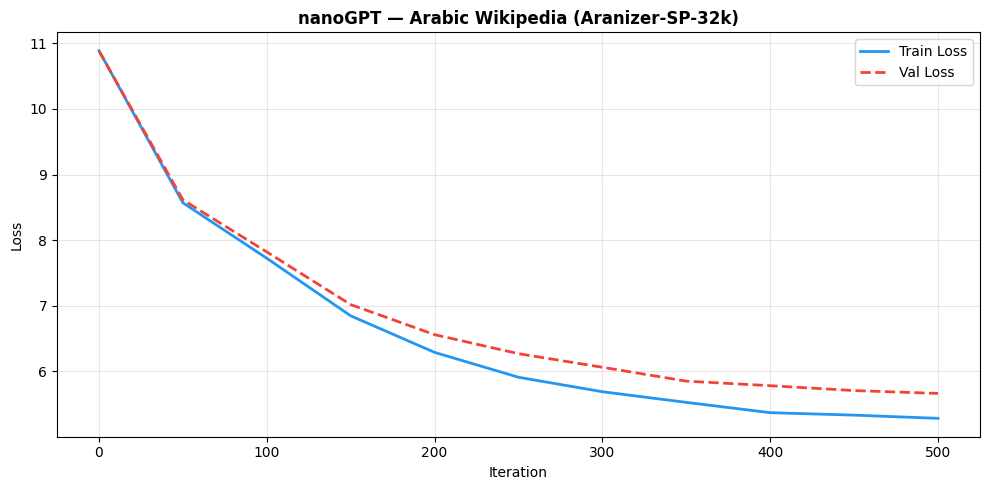

Best val loss  : 5.6626
Final val loss : 5.6626


In [13]:
import re, matplotlib.pyplot as plt

val_steps, train_losses, val_losses = [], [], []

with open('training_log.txt') as f:
    for line in f:
        m = re.search(r'step (\d+): train loss ([\d.]+), val loss ([\d.]+)', line)
        if m:
            val_steps.append(int(m.group(1)))
            train_losses.append(float(m.group(2)))
            val_losses.append(float(m.group(3)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(val_steps, train_losses, label='Train Loss', color='#2196F3', linewidth=2)
ax.plot(val_steps, val_losses,   label='Val Loss',   color='#F44336', linewidth=2, linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('nanoGPT — Arabic Wikipedia (Aranizer-SP-32k)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_plot.png', dpi=150)
plt.show()

if val_losses:
    print(f'Best val loss  : {min(val_losses):.4f}')
    print(f'Final val loss : {val_losses[-1]:.4f}')


## Step 10: Generate Arabic Text

In [11]:
import torch, sys
sys.path.insert(0, '.')
from model import GPTConfig, GPT

device = 'cuda' if torch.cuda.is_available() else 'cpu'
ckpt = torch.load('out-arabic/ckpt.pt', map_location=device)
model = GPT(GPTConfig(**ckpt['model_args']))
model.load_state_dict(ckpt['model'])
model.eval().to(device)

prompt = 'اللغة العربية هي'
ids = tokenizer.encode(prompt, add_special_tokens=False)
x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

with torch.no_grad():
    y = model.generate(x, max_new_tokens=100, temperature=0.8, top_k=50)

print(tokenizer.decode(y[0].tolist()))

number of parameters: 29.94M
اللغة العربية هي اللغة العربية والنسبية واللغرافية، واللغة العربية العربية؛ في الإسلام في اللغة العربية؛ فهي لغة السلالات غير رسمية وهي لغة أصلية في اللغة العربية في اللغة العربية اللغة العربية، كما تستخدم في اللغة العربية على أساسها العربية في العربية على المستوى الأفريقي، كما يوجد في اللغة الإنجليزية في اللغة العربية حيث اللغة العربية العربية في حين أن اللغة العربية التي تحتوي على من اللغة العربية التي تعني اللغة العربية في اللغة العربية والعربية في اللغة العربية وهي اللغة العربية هي اللغة العربية في اللغة العربية العربية الرسمية للبلاد.




## (Optional) Download Outputs

In [12]:
from google.colab import files
files.download('loss_plot.png')
# files.download('out-arabic/ckpt.pt')  # uncomment لتحميل الموديل

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>